# EMG Channel Reduction — Raw Signal Clustering

Groups 24 sEMG channels into **8 clusters** based on Pearson correlation of raw preprocessed signals.

**What this captures:** spatial electrode overlap and muscle co-activation patterns.
Two channels are 'similar' if their amplitude envelopes move together across all reps.

**Pipeline:**
1. Load per-subject .mat files (1500 samples x 24 channels per rep)
2. Stack all reps into one matrix (N_reps x 1500, 24)
3. Compute 24x24 Pearson correlation matrix
4. Agglomerative clustering — average linkage, correlation distance
5. Cut at k=8, select one representative per cluster via medoid

In [14]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform   # converts square dist matrix <-> condensed 1-D vector
from sklearn.metrics import silhouette_score    # validates whether k=8 is a good choice

# make the shared emg_loader module importable from the parent repo root
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
PUBLIC    = os.path.join(REPO_ROOT, 'public')
if PUBLIC not in sys.path:
    sys.path.insert(0, PUBLIC)

from emg_loader import load_all_subjects
print('Imports OK.')

Imports OK.


In [15]:
DATA_DIR      = '/Volumes/KRIS/data/UG_per_subject'   # folder of per-subject .mat files
N_CH_CLUSTERS = 8     # target number of channel groups
N_CHANNELS    = 24    # total sEMG channels in the putEMG setup

In [17]:
# load_all_subjects returns a list of (name, X, Y) tuples
# X shape per subject: (N_reps, 1, 24, 1500)
#   N_reps = number of gesture repetitions for this subject
#   1      = dummy channel dimension added by _reshape in emg_loader
#   24     = sEMG channels
#   1500   = resampled time samples per rep
subjects = load_all_subjects(DATA_DIR)
print(f'Loaded {len(subjects)} subjects')

# undo the _reshape and collect the raw signal for every rep as a (1500, 24) array
# X[i, 0, :, :] gives (24, 1500)  ->  .T flips it to (1500, 24)
all_signals = []
for _name, X, _Y in subjects:
    for i in range(X.shape[0]):
        all_signals.append(X[i, 0, :, :].T)   # (1500, 24)

# stack across all reps and subjects into one long time series per channel
raw = np.concatenate(all_signals, axis=0)      # (N_reps_total * 1500, 24)
print(f'Raw signal matrix: {raw.shape}  (time samples x channels)')

Loading 44 subject file(s) from: /Volumes/KRIS/data/UG_per_subject

  → emg_gestures_03_U.mat  (280 samples)
  → emg_gestures_04_U.mat  (280 samples)
  → emg_gestures_05_U.mat  (280 samples)
  → emg_gestures_06_U.mat  (280 samples)
  → emg_gestures_07_U.mat  (280 samples)
  → emg_gestures_08_U.mat  (280 samples)
  → emg_gestures_09_U.mat  (280 samples)
  → emg_gestures_10_U.mat  (280 samples)
  → emg_gestures_11_U.mat  (280 samples)
  → emg_gestures_12_U.mat  (280 samples)
  → emg_gestures_13_U.mat  (280 samples)
  → emg_gestures_14_U.mat  (280 samples)
  → emg_gestures_15_U.mat  (280 samples)
  → emg_gestures_16_U.mat  (280 samples)
  → emg_gestures_17_U.mat  (280 samples)
  → emg_gestures_18_U.mat  (280 samples)
  → emg_gestures_19_U.mat  (280 samples)
  → emg_gestures_20_U.mat  (280 samples)
  → emg_gestures_22_U.mat  (280 samples)
  → emg_gestures_23_U.mat  (280 samples)
  → emg_gestures_24_U.mat  (280 samples)
  → emg_gestures_25_U.mat  (280 samples)
  → emg_gestures_26_U.mat  (28

Off-diagonal corr  min=0.558  max=0.948  mean=0.768


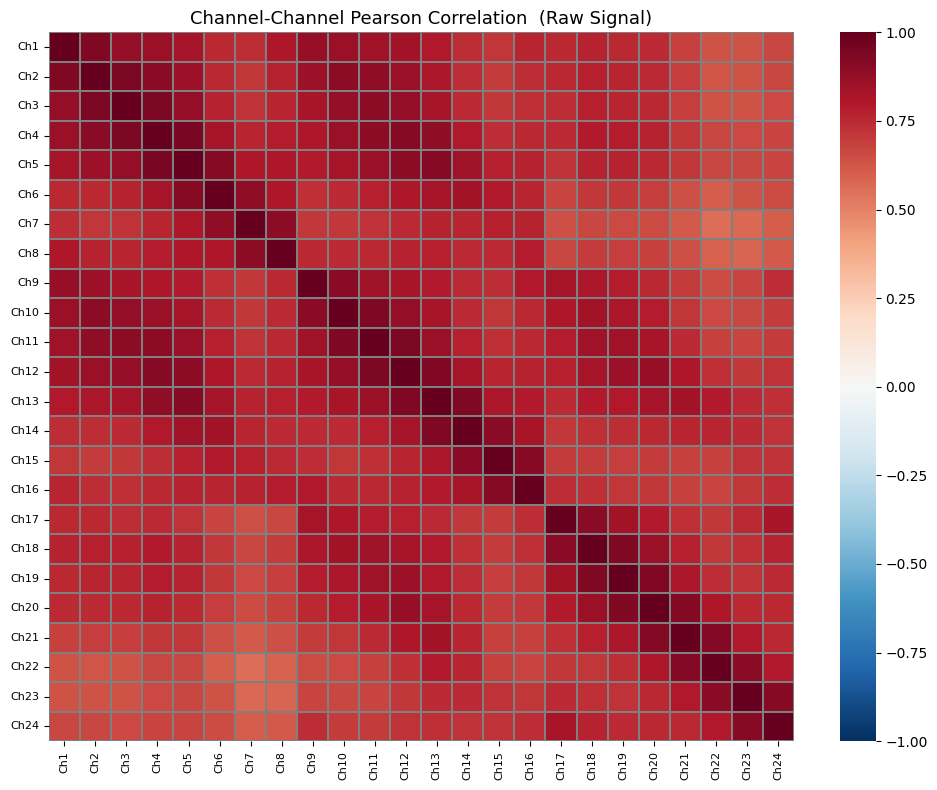

In [18]:
# Pearson correlation between every pair of channels.
# np.corrcoef expects (variables, observations), so we transpose: (24, N_samples)
# corr_matrix[i, j] = linear co-activation of channel i and channel j
# range: -1 (perfectly opposite) to +1 (perfectly co-activate)
corr_matrix = np.corrcoef(raw.T)   # (24, 24)
np.fill_diagonal(corr_matrix, 1.0) # ensure exact 1s on diagonal (no float drift)

# quick sanity check: high mean off-diagonal corr means many channels are redundant
mask = ~np.eye(N_CHANNELS, dtype=bool)
print(f'Off-diagonal corr  min={corr_matrix[mask].min():.3f}  '
      f'max={corr_matrix[mask].max():.3f}  '
      f'mean={corr_matrix[mask].mean():.3f}')

# visualise the full 24x24 correlation matrix as a heatmap
ch_labels = [f'Ch{i+1}' for i in range(N_CHANNELS)]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r',
            xticklabels=ch_labels, yticklabels=ch_labels,
            ax=ax, linewidths=0.3, linecolor='grey')
ax.set_title('Channel-Channel Pearson Correlation  (Raw Signal)', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('raw_correlation_heatmap.png', dpi=150)
plt.show()

In [19]:
def plot_dendrogram_with_cut(
    Z,
    k,
    n_channels=24,
    title='Channel Dendrogram',
    save_path=None,
    representative_channels=None,
):
    # -----------------------------------------------------------------------
    # Draw the agglomerative clustering dendrogram and overlay a dashed red
    # line at the height that produces exactly k clusters.
    #
    # How the cut height works:
    #   Z is a (n-1, 4) linkage matrix. Each row records one merge:
    #     [left_child, right_child, merge_distance, cluster_size]
    #   Rows are ordered from smallest to largest merge distance.
    #   Z[-(k-1), 2] is the distance at which we go from k+1 -> k clusters,
    #   so cutting at this height gives exactly k groups.
    # -----------------------------------------------------------------------
    cut_height = Z[-(k - 1), 2]   # height that yields exactly k clusters
    ch_labels  = [f'Ch{i+1}' for i in range(n_channels)]

    fig, ax = plt.subplots(figsize=(14, 5))

    # color_threshold colours each subtree below the cut differently
    # so you can visually see the k groups
    dendrogram(
        Z,
        labels=ch_labels,
        color_threshold=cut_height,
        ax=ax,
        leaf_rotation=0,
        leaf_font_size=10,
    )

    # dashed horizontal line showing exactly where the tree is cut
    ax.axhline(
        cut_height, color='red', linestyle='--', linewidth=1.5,
        label=f'k={k} cut  (dist={cut_height:.4f})',
    )
    ax.legend(fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Channel')
    ax.set_ylabel('Correlation distance  (1 - r)')

    # place a red star below each leaf that was selected as cluster representative
    if representative_channels:
        ylim   = ax.get_ylim()
        offset = (ylim[1] - ylim[0]) * 0.07   # push star slightly below the x-axis
        for tick in ax.get_xticklabels():
            ch_idx = int(tick.get_text().replace('Ch', '')) - 1
            if ch_idx in representative_channels:
                ax.text(
                    tick.get_position()[0],
                    ylim[0] - offset,
                    chr(9733),            # unicode filled star
                    ha='center', va='top', fontsize=13, color='red',
                    transform=ax.transData,
                )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Cut height : {cut_height:.4f}')
    print(f'Clusters   : {k}')

In [20]:
# --- Step 1: convert correlation to a distance metric ---
# distance = 1 - r, so r=1 (identical channels) -> dist=0,
# and r=0 (uncorrelated) -> dist=1
# clip at 0 prevents tiny negative values from floating-point subtraction
dist_matrix = np.clip(1.0 - corr_matrix, 0.0, None)

# FIX: enforce exact symmetry before calling squareform
# np.corrcoef can produce corr[i,j] != corr[j,i] by ~1e-16 due to float arithmetic
# squareform checks D == D.T elementwise and raises ValueError if they differ at all
# averaging D and D.T collapses those micro-differences to zero
dist_matrix = (dist_matrix + dist_matrix.T) / 2

# diagonal must be exactly 0 (distance from a channel to itself)
np.fill_diagonal(dist_matrix, 0.0)

# --- Step 2: build the linkage matrix ---
# squareform converts the (24, 24) matrix to a condensed 1-D vector (upper triangle)
# this is the format scipy linkage() requires as input
condensed = squareform(dist_matrix)

# average linkage: distance between two clusters = mean of all pairwise member distances
# good middle ground between single linkage (chaining) and complete linkage (compactness)
Z = linkage(condensed, method='average')

# --- Step 3: cut the tree at k clusters ---
# fcluster finds the minimum cut height that produces exactly k non-empty clusters
# subtract 1 to convert from scipy's 1-indexed labels to 0-indexed
cluster_labels = fcluster(Z, N_CH_CLUSTERS, criterion='maxclust') - 1

print('Cluster composition:')
for c in range(N_CH_CLUSTERS):
    members = np.where(cluster_labels == c)[0]
    print(f'  Cluster {c}: channels {list(members + 1)}')

Cluster composition:
  Cluster 0: channels [np.int64(23), np.int64(24)]
  Cluster 1: channels [np.int64(20), np.int64(21), np.int64(22)]
  Cluster 2: channels [np.int64(17), np.int64(18), np.int64(19)]
  Cluster 3: channels [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10), np.int64(11), np.int64(12)]
  Cluster 4: channels [np.int64(9)]
  Cluster 5: channels [np.int64(6), np.int64(7), np.int64(8)]
  Cluster 6: channels [np.int64(13), np.int64(14)]
  Cluster 7: channels [np.int64(15), np.int64(16)]


In [21]:
# Representative selection: medoid strategy
# The medoid is the channel most central to its cluster —
# the one with the highest average Pearson r to every other member.
# More robust than a centroid because we stay in the original channel space
# (no interpolated 'average channel' that may not correspond to a real electrode).
representative_channels = []

for c in range(N_CH_CLUSTERS):
    members  = np.where(cluster_labels == c)[0]          # 0-indexed channel indices
    sub_corr = corr_matrix[np.ix_(members, members)]     # sub-matrix for this cluster only
    avg_corr = sub_corr.mean(axis=1)                     # mean corr of each member to all others
    rep      = members[np.argmax(avg_corr)]              # pick the most central channel
    representative_channels.append(rep)
    print(f'  Cluster {c}: {list(members + 1)}  ->  Ch{rep + 1} (idx {rep})')

# sort so channel indices are in ascending order
representative_channels = sorted(representative_channels)
print()
print(f'Final representatives (0-indexed): {representative_channels}')
print(f'Final representatives (1-indexed): {[c + 1 for c in representative_channels]}')

  Cluster 0: [np.int64(23), np.int64(24)]  ->  Ch23 (idx 22)
  Cluster 1: [np.int64(20), np.int64(21), np.int64(22)]  ->  Ch21 (idx 20)
  Cluster 2: [np.int64(17), np.int64(18), np.int64(19)]  ->  Ch18 (idx 17)
  Cluster 3: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(10), np.int64(11), np.int64(12)]  ->  Ch4 (idx 3)
  Cluster 4: [np.int64(9)]  ->  Ch9 (idx 8)
  Cluster 5: [np.int64(6), np.int64(7), np.int64(8)]  ->  Ch7 (idx 6)
  Cluster 6: [np.int64(13), np.int64(14)]  ->  Ch13 (idx 12)
  Cluster 7: [np.int64(15), np.int64(16)]  ->  Ch15 (idx 14)

Final representatives (0-indexed): [np.int64(3), np.int64(6), np.int64(8), np.int64(12), np.int64(14), np.int64(17), np.int64(20), np.int64(22)]
Final representatives (1-indexed): [np.int64(4), np.int64(7), np.int64(9), np.int64(13), np.int64(15), np.int64(18), np.int64(21), np.int64(23)]


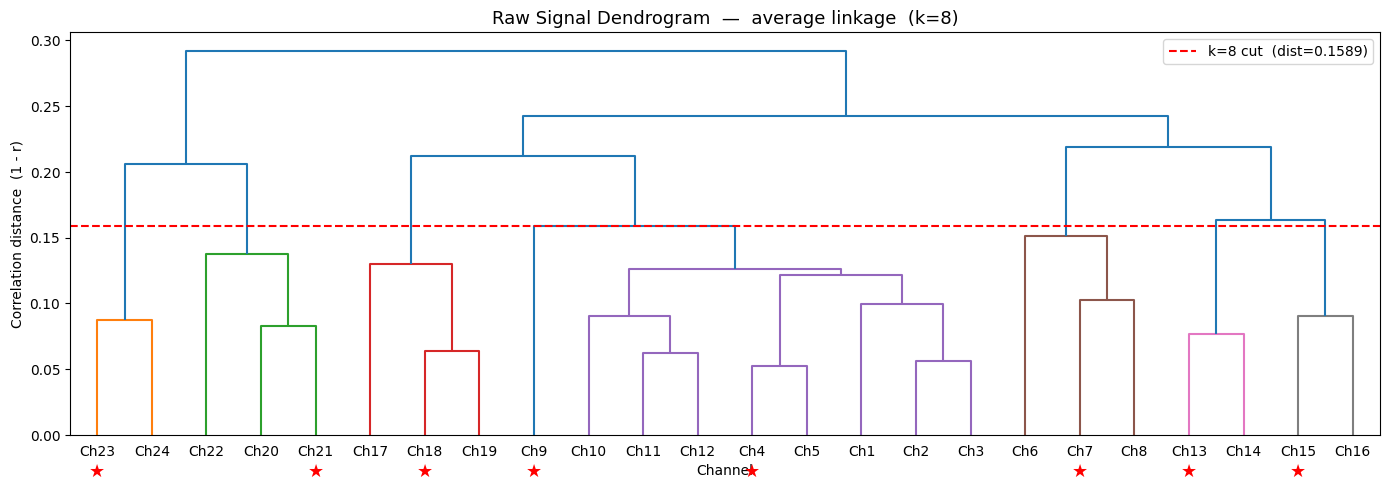

Cut height : 0.1589
Clusters   : 8


In [12]:
# call the display function — change k here to explore other cut points
plot_dendrogram_with_cut(
    Z,
    k=N_CH_CLUSTERS,
    title=f'Raw Signal Dendrogram  —  average linkage  (k={N_CH_CLUSTERS})',
    save_path='raw_dendrogram.png',
    representative_channels=representative_channels,
)

  k= 2  silhouette=0.3098
  k= 3  silhouette=0.2878
  k= 4  silhouette=0.3023
  k= 5  silhouette=0.3372
  k= 6  silhouette=0.3639
  k= 7  silhouette=0.3458
  k= 8  silhouette=0.2822
  k= 9  silhouette=0.2562
  k=10  silhouette=0.2169
  k=11  silhouette=0.2050
  k=12  silhouette=0.2156


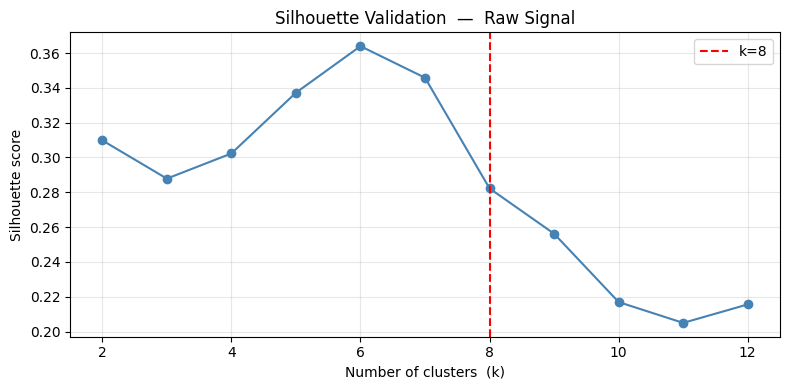

In [22]:
# Silhouette score measures how well each channel fits its assigned cluster
# vs. the nearest other cluster.  Range: -1 (wrong cluster) to +1 (well separated).
# Sweeping k=2..12 shows whether k=8 sits near a local maximum,
# which confirms it is a natural breakpoint in the channel similarity structure.
k_range    = range(2, 13)
sil_scores = []

for k in k_range:
    labels_k = fcluster(Z, k, criterion='maxclust') - 1
    # metric='precomputed' tells sklearn to treat dist_matrix as distances directly
    score    = silhouette_score(dist_matrix, labels_k, metric='precomputed')
    sil_scores.append(score)
    print(f'  k={k:>2}  silhouette={score:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), sil_scores, marker='o', color='steelblue', linewidth=1.5)
ax.axvline(N_CH_CLUSTERS, color='red', linestyle='--', label=f'k={N_CH_CLUSTERS}')
ax.set_xlabel('Number of clusters  (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Validation  —  Raw Signal')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('raw_silhouette.png', dpi=150)
plt.show()

In [23]:
# persist results so other notebooks can load them without re-running clustering
np.save('raw_representative_channels.npy', np.array(representative_channels))  # shape (8,)
np.save('raw_cluster_labels.npy', cluster_labels)                               # shape (24,)
print('Saved:  raw_representative_channels.npy   raw_cluster_labels.npy')
print(f'Selected channels (1-indexed): {[c + 1 for c in representative_channels]}')

Saved:  raw_representative_channels.npy   raw_cluster_labels.npy
Selected channels (1-indexed): [np.int64(4), np.int64(7), np.int64(9), np.int64(13), np.int64(15), np.int64(18), np.int64(21), np.int64(23)]
